feat_finger              : 0.4533 seconds
feat_finger_type         : 0.2453 seconds
feat_movement            : 0.1729 seconds
feat_reach               : 0.1706 seconds
feat_coords              : 0.1460 seconds
0. Setup Array Masks     : 0.1016 seconds
0. Build Lookup Matrices : 0.0830 seconds
feat_same_finger_skipgram: 0.0617 seconds
feat_out_triroll         : 0.0573 seconds
feat_same_finger_trigram : 0.0557 seconds
feat_redirects           : 0.0527 seconds
feat_in_triroll          : 0.0522 seconds
feat_scissors            : 0.0414 seconds
feat_double_row_jump     : 0.0399 seconds
feat_same_finger         : 0.0397 seconds
feat_out_roll            : 0.0378 seconds
feat_in_roll             : 0.0362 seconds
feat_same_hand           : 0.0351 seconds
feat_hand                : 0.0274 seconds
feat_shift               : 0.0272 seconds


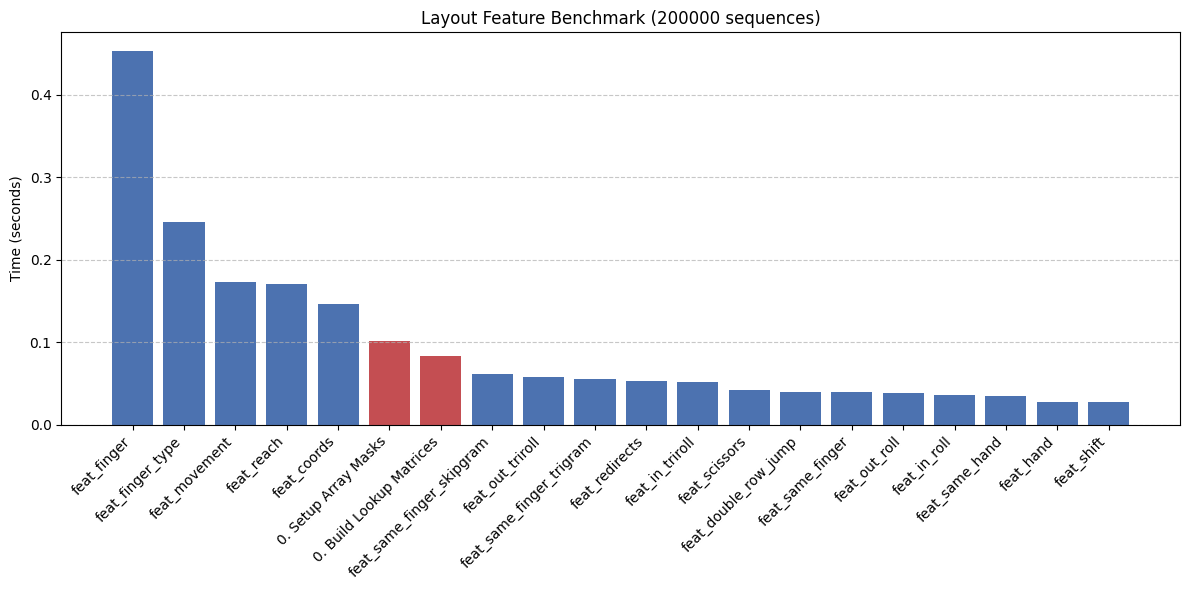

In [ ]:
import os
import sys
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.enrichment.engine import EnrichmentEngine

input_path = os.path.join(project_root, "data/interim/linguistic_features.parquet")
layout_paths = {
    "layout": os.path.join(project_root, "data/layouts/qwerty_us.json"),
    "map": os.path.join(project_root, "data/layouts/layout_map.json"),
    "shifts": os.path.join(project_root, "data/layouts/shifts_us.json"),
    "movement": os.path.join(project_root, "data/layouts/movement_features.json")
}

subset_n = 200000

if not os.path.exists(input_path):
    print(f"File not found: {input_path}\nPlease run enrich_linguistic.py first.")
else:
    df = pd.read_parquet(input_path)
    if subset_n:
        unique_ids = df['sequence_id'].unique()[:subset_n]
        df = df[df['sequence_id'].isin(unique_ids)].copy()

    times = {}

    t0 = time.perf_counter()
    engine = EnrichmentEngine(movement_features_path=layout_paths.get('movement'))
    with open(layout_paths['layout'], 'r') as f: l_data = json.load(f)
    with open(layout_paths['map'], 'r') as f: l_map = json.load(f)
    with open(layout_paths['shifts'], 'r') as f: s_data = json.load(f)
    
    features =["finger", "finger_type", "hand", "coords", "shift"]
    tables, move_matrix, _, sf_matrix, sh_matrix, sft_matrix, ir_matrix, or_matrix, _, _, sf_skip_matrix, in_triroll_matrix, out_triroll_matrix, redir_matrix, drj_matrix, scissor_matrix = engine._build_lookups(l_data, l_map, s_data, features)
    times['0. Build Lookup Matrices'] = time.perf_counter() - t0

    t0 = time.perf_counter()
    encoded = df['key_id'].values
    mask = (encoded == 0)
    p = pd.Series(encoded).shift(1).fillna(0).astype(int).values
    pp = pd.Series(encoded).shift(2).fillna(0).astype(int).values
    valid_bi = (p != 0) & (encoded != 0) & (p < 128) & (encoded < 128)
    valid_tri = valid_bi & (pp != 0) & (pp < 128)
    times['0. Setup Array Masks'] = time.perf_counter() - t0

    for feat, table in tables.items():
        t0 = time.perf_counter()
        data = table[encoded].astype(np.float32)
        if data.ndim == 1:
            data[mask] = -1.0 if feat in ["hand", "shift"] else 0.0
            df[feat] = data
        else:
            data[mask, :] = np.nan if feat in ["coords", "reach"] else 0.0
            if feat == 'coords':
                df['x'] = data[:, 0]; df['y'] = data[:, 1]
            elif feat == 'reach':
                df['reach_dist'] = data[:, 0]; df['reach_sin'] = data[:, 1]; df['reach_cos'] = data[:, 2]
            elif feat == 'finger':
                for i in range(10): df[f'finger_{i}'] = data[:, i]
            elif feat == 'finger_type':
                for i in range(5): df[f'finger_type_{i}'] = data[:, i]
        times[f'feat_{feat}'] = time.perf_counter() - t0

    def time_assign(name, v_mask, matrix, idxs):
        if matrix is None: return
        t0 = time.perf_counter()
        df[name] = np.where(v_mask, matrix[idxs], np.nan)
        times[f'feat_{name}'] = time.perf_counter() - t0

    time_assign('same_finger', valid_bi, sf_matrix, (p, encoded))
    time_assign('same_hand', valid_bi, sh_matrix, (p, encoded))
    time_assign('in_roll', valid_bi, ir_matrix, (p, encoded))
    time_assign('out_roll', valid_bi, or_matrix, (p, encoded))
    time_assign('double_row_jump', valid_bi, drj_matrix, (p, encoded))
    time_assign('scissors', valid_bi, scissor_matrix, (p, encoded))
    
    time_assign('same_finger_trigram', valid_tri, sft_matrix, (pp, p, encoded))
    time_assign('same_finger_skipgram', valid_tri, sf_skip_matrix, (pp, p, encoded))
    time_assign('in_triroll', valid_tri, in_triroll_matrix, (pp, p, encoded))
    time_assign('out_triroll', valid_tri, out_triroll_matrix, (pp, p, encoded))
    time_assign('redirects', valid_tri, redir_matrix, (pp, p, encoded))

    t0 = time.perf_counter()
    if move_matrix is not None:
        m_data = np.full((len(encoded), 3), np.nan, dtype=np.float32)
        m_data[valid_bi] = move_matrix[p[valid_bi], encoded[valid_bi]]
        df['move_dist'] = m_data[:, 0]
        df['move_sin'] = m_data[:, 1]
        df['move_cos'] = m_data[:, 2]
    times['feat_movement'] = time.perf_counter() - t0

    sorted_times = dict(sorted(times.items(), key=lambda item: item[1], reverse=True))

    for feature, t in sorted_times.items():
        print(f"{feature:<25}: {t:.4f} seconds")

    plt.figure(figsize=(12, 6))
    colors =['#C44E52' if '0. ' in k else '#4C72B0' for k in sorted_times.keys()]
    plt.bar(sorted_times.keys(), sorted_times.values(), color=colors)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Time (seconds)')
    plt.title(f'Layout Feature Benchmark ({subset_n} sequences)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()